# 🔁 Repurchase Propensity Model — Online Retail

---

Predict whether a customer will make a **repeat purchase** within a future time window.

### Methodology

| Phase | Description |
|---|---|
| **Feature Window** | Historical period used to build customer-level features |
| **Target Window** | Future period used to define the binary repurchase label |
| **Target span** | 80th percentile of the distribution of average inter-purchase days |
| **Label** | `is_repurchaser = 1` if a Feature Window customer appears in the Target Window |

### Steps

1. Data loading & cleaning (reusing EDA pipeline)
2. Inter-purchase day distribution → target window span
3. Feature / Target window split
4. Target variable construction
5. Feature engineering
6. Model training (Logistic Regression · Random Forest · XGBoost)
7. Evaluation & feature importance

## 0. Setup & Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay,
    average_precision_score, PrecisionRecallDisplay,
)
import xgboost as xgb

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_PATH = 'Online Retail.xlsx'
RANDOM_STATE = 42
print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
# ── Load & clean (identical pipeline from eda-online-retail.ipynb) ──────────
df_raw = pd.read_excel(DATA_PATH, engine='openpyxl')
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])

df = (
    df_raw
    .drop_duplicates()
    .dropna(subset=['CustomerID'])
    .loc[lambda d: ~d['InvoiceDate'].isna()]
    .loc[lambda d: ~d['InvoiceNo'].astype(str).str.startswith('C')]
    .loc[lambda d: d['Quantity'] > 0]
    .loc[lambda d: d['UnitPrice'] > 0]
    .copy()
)

qty_99th = df['Quantity'].quantile(0.99)
df['Quantity'] = df['Quantity'].clip(upper=qty_99th)

df['CustomerID'] = df['CustomerID'].astype(int)
df['Revenue']    = df['Quantity'] * df['UnitPrice']
df = df.reset_index(drop=True)

df = df[df['Country'] == 'United Kingdom']
df = df[df['InvoiceDate'] <= '2011-11-30 23:59:59'].copy()

print(f'Clean dataset: {len(df):,} rows | {df["CustomerID"].nunique():,} unique customers')
print(f'Date range   : {df["InvoiceDate"].min().date()}  →  {df["InvoiceDate"].max().date()}')
df.head(3)

Clean dataset: 333,680 rows | 3,886 unique customers
Date range   : 2010-12-01  →  2011-11-30


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00


## 1. Inter-purchase Day Distribution → Target Window Span

For each customer we compute the **average number of days between consecutive orders**.
The **80th percentile** of that distribution defines how many days forward we look for a repurchase.

In [3]:
# ── Deduplicate to one row per customer × invoice date ──────────────────────
order_dates = (
    df.groupby(['CustomerID', 'InvoiceNo'])['InvoiceDate']
    .min()
    .reset_index()
    .rename(columns={'InvoiceDate': 'OrderDate'})
    .sort_values(['CustomerID', 'OrderDate'])
)

# ── Gap between consecutive orders per customer ──────────────────────────────
order_dates['PrevOrderDate'] = order_dates.groupby('CustomerID')['OrderDate'].shift(1)
order_dates['DaysBetween']   = (
    order_dates['OrderDate'] - order_dates['PrevOrderDate']
).dt.days

# Keep only customers with at least 2 orders (so a gap exists)
avg_ipt = (
    order_dates
    .dropna(subset=['DaysBetween'])
    .groupby('CustomerID')['DaysBetween']
    .mean()
    .rename('AvgDaysBetweenOrders')
)

p80 = int(np.percentile(avg_ipt, 80))

print('=== Inter-purchase Time Distribution ===')
print(avg_ipt.describe().to_string())
print(f'\n📅  80th percentile = {p80} days  →  TARGET WINDOW SPAN')

=== Inter-purchase Time Distribution ===
count    2491.000000
mean       71.897341
std        65.228580
min         0.000000
25%        28.833333
50%        53.000000
75%        91.000000
max       364.000000

📅  80th percentile = 105 days  →  TARGET WINDOW SPAN


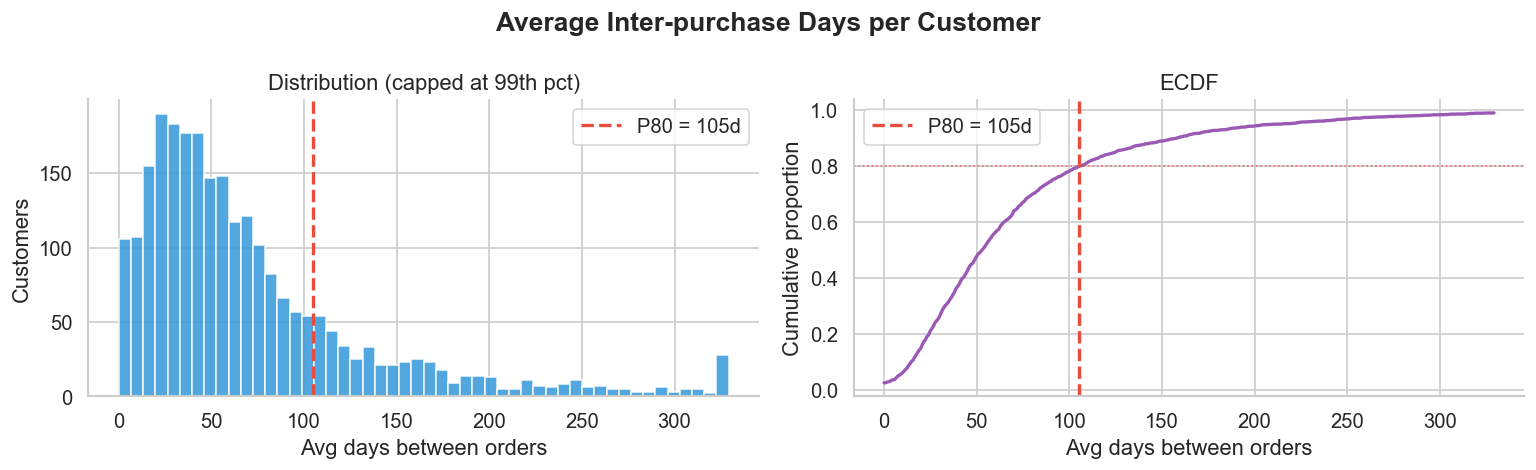

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Average Inter-purchase Days per Customer', fontweight='bold')

# Histogram
axes[0].hist(avg_ipt.clip(upper=avg_ipt.quantile(0.99)), bins=50,
             color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(p80, color='#e74c3c', lw=2, ls='--', label=f'P80 = {p80}d')
axes[0].set_xlabel('Avg days between orders'); axes[0].set_ylabel('Customers')
axes[0].set_title('Distribution (capped at 99th pct)')
axes[0].legend()

# ECDF
from statsmodels.distributions.empirical_distribution import ECDF
ecdf = ECDF(avg_ipt)
x = np.linspace(0, avg_ipt.quantile(0.99), 400)
axes[1].plot(x, ecdf(x), color='#9b59b6', lw=2)
axes[1].axvline(p80, color='#e74c3c', lw=2, ls='--', label=f'P80 = {p80}d')
axes[1].axhline(0.80, color='#e74c3c', lw=1, ls=':', alpha=0.7)
axes[1].set_xlabel('Avg days between orders'); axes[1].set_ylabel('Cumulative proportion')
axes[1].set_title('ECDF')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Feature Window / Target Window Split


- **Feature Window**: all transactions strictly before the `cutoff` date
- **Target Window**: transactions from `cutoff` (inclusive) to the end of the dataset

In [5]:
max_date   = df['InvoiceDate'].max()
cutoff     = max_date - pd.Timedelta(days=p80)

df_feat   = df[df['InvoiceDate'] <  cutoff].copy()
df_target = df[df['InvoiceDate'] >= cutoff].copy()

print('=== Window Summary ===')
print(f'  Full dataset  : {df["InvoiceDate"].min().date()} → {max_date.date()}')
print(f'  Target span   : {p80} days  (80th percentile)')
print(f'  Cutoff date   : {cutoff.date()}')
print()
print(f'  Feature Window: {df_feat["InvoiceDate"].min().date()} → {df_feat["InvoiceDate"].max().date()}')
print(f'    Rows         : {len(df_feat):,}')
print(f'    Customers    : {df_feat["CustomerID"].nunique():,}')
print()
print(f'  Target Window : {df_target["InvoiceDate"].min().date()} → {df_target["InvoiceDate"].max().date()}')
print(f'    Rows         : {len(df_target):,}')
print(f'    Customers    : {df_target["CustomerID"].nunique():,}')

=== Window Summary ===
  Full dataset  : 2010-12-01 → 2011-11-30
  Target span   : 105 days  (80th percentile)
  Cutoff date   : 2011-08-17

  Feature Window: 2010-12-01 → 2011-08-17
    Rows         : 187,996
    Customers    : 2,930

  Target Window : 2011-08-17 → 2011-11-30
    Rows         : 145,684
    Customers    : 2,675


## 3. Target Variable: `is_repurchaser`

A customer is labelled **1** (repurchaser) if their `CustomerID` appears at least once in the Target Window.
Only customers present in the Feature Window are included in the modelling dataset.

=== Target Variable Distribution ===
  Total customers  : 2,930
  Repurchasers (1) : 1,719  (58.7%)
  Non-repurchasers(0): 1,211  (41.3%)
  Class imbalance  : 1:0.7


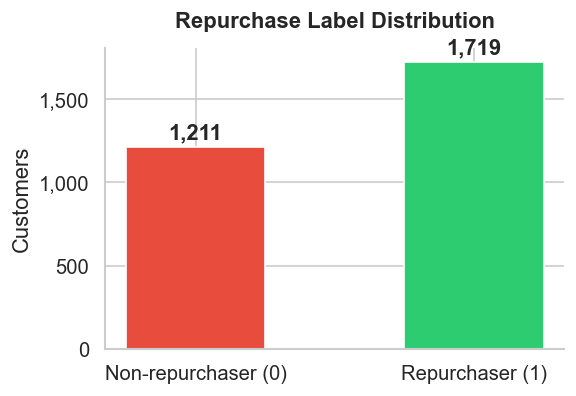

In [6]:
feature_customers = set(df_feat['CustomerID'].unique())
target_customers  = set(df_target['CustomerID'].unique())

# Ground truth: customers seen in the feature window
labels = pd.DataFrame({'CustomerID': list(feature_customers)})
labels['is_repurchaser'] = labels['CustomerID'].isin(target_customers).astype(int)

n_pos = labels['is_repurchaser'].sum()
n_neg = len(labels) - n_pos

print('=== Target Variable Distribution ===')
print(f'  Total customers  : {len(labels):,}')
print(f'  Repurchasers (1) : {n_pos:,}  ({n_pos/len(labels)*100:.1f}%)')
print(f'  Non-repurchasers(0): {n_neg:,}  ({n_neg/len(labels)*100:.1f}%)')
print(f'  Class imbalance  : 1:{n_neg/n_pos:.1f}')

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['Non-repurchaser (0)', 'Repurchaser (1)'], [n_neg, n_pos],
       color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
for i, v in enumerate([n_neg, n_pos]):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
ax.set_title('Repurchase Label Distribution', fontweight='bold', pad=12)
ax.set_ylabel('Customers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [11]:
max_date   = df['InvoiceDate'].max()
cutoff     = max_date - pd.Timedelta(days=60)

df_feat   = df[df['InvoiceDate'] <  cutoff].copy()
df_target = df[df['InvoiceDate'] >= cutoff].copy()

print('=== Window Summary ===')
print(f'  Full dataset  : {df["InvoiceDate"].min().date()} → {max_date.date()}')
print(f'  Target span   : {p80} days  (80th percentile)')
print(f'  Cutoff date   : {cutoff.date()}')
print()
print(f'  Feature Window: {df_feat["InvoiceDate"].min().date()} → {df_feat["InvoiceDate"].max().date()}')
print(f'    Rows         : {len(df_feat):,}')
print(f'    Customers    : {df_feat["CustomerID"].nunique():,}')
print()
print(f'  Target Window : {df_target["InvoiceDate"].min().date()} → {df_target["InvoiceDate"].max().date()}')
print(f'    Rows         : {len(df_target):,}')
print(f'    Customers    : {df_target["CustomerID"].nunique():,}')

=== Window Summary ===
  Full dataset  : 2010-12-01 → 2011-11-30
  Target span   : 105 days  (80th percentile)
  Cutoff date   : 2011-10-01

  Feature Window: 2010-12-01 → 2011-09-30
    Rows         : 233,227
    Customers    : 3,265

  Target Window : 2011-10-02 → 2011-11-30
    Rows         : 100,453
    Customers    : 2,181


In [12]:
feature_customers = set(df_feat['CustomerID'].unique())
target_customers  = set(df_target['CustomerID'].unique())

# Ground truth: customers seen in the feature window
labels = pd.DataFrame({'CustomerID': list(feature_customers)})
labels['is_repurchaser'] = labels['CustomerID'].isin(target_customers).astype(int)

n_pos = labels['is_repurchaser'].sum()
n_neg = len(labels) - n_pos

print('=== Target Variable Distribution ===')
print(f'  Total customers  : {len(labels):,}')
print(f'  Repurchasers (1) : {n_pos:,}  ({n_pos/len(labels)*100:.1f}%)')
print(f'  Non-repurchasers(0): {n_neg:,}  ({n_neg/len(labels)*100:.1f}%)')
print(f'  Class imbalance  : 1:{n_neg/n_pos:.1f}')

=== Target Variable Distribution ===
  Total customers  : 3,265
  Repurchasers (1) : 1,560  (47.8%)
  Non-repurchasers(0): 1,705  (52.2%)
  Class imbalance  : 1:1.1


## 4. Feature Engineering

All features are computed exclusively from the **Feature Window** to avoid data leakage.

| Feature | Description |
|---|---|
| `recency_days` | Days between last purchase and cutoff date |
| `frequency` | Number of distinct invoices |
| `monetary` | Total revenue (£) |
| `aov` | Average order value (monetary / frequency) |
| `avg_ipt` | Average inter-purchase time in days (NaN → filled with cutoff span) |
| `unique_products` | Number of distinct StockCodes purchased |
| `customer_tenure` | Days between first and cutoff date |
| `purchase_span` | Days between first and last purchase |
| `orders_per_month` | frequency / (customer_tenure / 30) |

In [13]:
# ── Order-level aggregation in the Feature Window ───────────────────────────
# One row per customer × invoice
feat_orders = (
    df_feat
    .groupby(['CustomerID', 'InvoiceNo'])
    .agg(
        OrderDate  = ('InvoiceDate', 'min'),
        OrderRev   = ('Revenue', 'sum'),
    )
    .reset_index()
    .sort_values(['CustomerID', 'OrderDate'])
)

# ── Inter-purchase time per customer (in feature window) ─────────────────────
feat_orders['PrevOrder'] = feat_orders.groupby('CustomerID')['OrderDate'].shift(1)
feat_orders['IPT']       = (feat_orders['OrderDate'] - feat_orders['PrevOrder']).dt.days
avg_ipt_feat = (
    feat_orders.dropna(subset=['IPT'])
    .groupby('CustomerID')['IPT']
    .mean()
    .rename('avg_ipt')
)

# ── Customer-level RFM + extras ───────────────────────────────────────────────
cust_agg = (
    df_feat
    .groupby('CustomerID')
    .agg(
        last_purchase     = ('InvoiceDate', 'max'),
        first_purchase    = ('InvoiceDate', 'min'),
        frequency         = ('InvoiceNo',   'nunique'),
        monetary          = ('Revenue',     'sum'),
        unique_products   = ('StockCode',   'nunique'),
    )
    .reset_index()
)

cust_agg['recency_days']    = (cutoff - cust_agg['last_purchase']).dt.days
cust_agg['customer_tenure'] = (cutoff - cust_agg['first_purchase']).dt.days
cust_agg['purchase_span']   = (cust_agg['last_purchase'] - cust_agg['first_purchase']).dt.days
cust_agg['aov']             = cust_agg['monetary'] / cust_agg['frequency']
cust_agg['orders_per_month']= cust_agg['frequency'] / (cust_agg['customer_tenure'].clip(lower=1) / 30)

# Merge avg inter-purchase time; customers with 1 order → fill with their tenure
cust_agg = cust_agg.merge(avg_ipt_feat.reset_index(), on='CustomerID', how='left')
cust_agg['avg_ipt'] = cust_agg['avg_ipt'].fillna(cust_agg['customer_tenure'])

# Drop datetime cols no longer needed
cust_agg = cust_agg.drop(columns=['last_purchase', 'first_purchase'])

print(f'Feature matrix shape: {cust_agg.shape}')
cust_agg.head(3)

Feature matrix shape: (3265, 10)


,CustomerID,frequency,monetary,unique_products,recency_days,customer_tenure,purchase_span,aov,orders_per_month,avg_ipt
0,12346,1,124.80,1,256,256,0,124.80000,0.117188,256.000000
1,12747,8,2769.40,34,40,300,259,346.17500,0.800000,36.857143
2,12748,139,19357.76,1304,1,304,303,139.26446,13.717105,1.818841


In [14]:
# ── Merge features with target label ────────────────────────────────────────
model_df = cust_agg.merge(labels, on='CustomerID')

FEATURE_COLS = [
    'recency_days', 'frequency', 'monetary', 'aov',
    'avg_ipt', 'unique_products', 
    'customer_tenure', 'purchase_span', 'orders_per_month',
]

X = model_df[FEATURE_COLS]
y = model_df['is_repurchaser']

print(f'Modelling dataset : {X.shape[0]:,} customers × {X.shape[1]} features')
print(f'Missing values    : {X.isnull().sum().sum()}')
print(f'Class balance     : {y.value_counts().to_dict()}')

# Quick feature overview
X.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

Modelling dataset : 3,265 customers × 9 features
Missing values    : 0
Class balance     : {0: 1705, 1: 1560}


,count,mean,std,min,25%,50%,75%,max
recency_days,3265.000000,93.149158,86.773741,1.000000,19.000000,65.000000,149.000000,304.000000
frequency,3265.000000,3.629096,5.842653,1.000000,1.000000,2.000000,4.000000,139.000000
monetary,3265.000000,1360.918687,3631.089137,2.900000,259.170000,548.310000,1316.630000,97239.850000
aov,3265.000000,335.552963,355.119789,2.900000,165.860000,272.077500,396.870000,13305.500000
avg_ipt,3265.000000,95.541185,81.891947,0.000000,32.000000,67.000000,142.000000,304.000000
unique_products,3265.000000,51.283614,68.480281,1.000000,14.000000,30.000000,64.000000,1304.000000
customer_tenure,3265.000000,191.159265,91.768860,1.000000,127.000000,206.000000,270.000000,304.000000
purchase_span,3265.000000,97.725881,104.782246,0.000000,0.000000,63.000000,192.000000,303.000000
orders_per_month,3265.000000,0.974075,2.673945,0.098684,0.223881,0.415225,0.810811,60.000000


## 5. Model Training

### Strategy
- Stratified 80 / 20 train-test split to preserve class balance.
- Three models, evaluated on held-out test set:
  1. **Logistic Regression** (scaled) — interpretable baseline
  2. **Random Forest** — handles non-linearity & interactions natively
  3. **XGBoost** — gradient boosted trees with built-in `scale_pos_weight` for imbalance

We report **ROC-AUC** (main metric), PR-AUC, and a full classification report at the 0.5 threshold.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size : {len(X_train):,}  ({y_train.mean()*100:.1f}% repurchasers)')
print(f'Test size  : {len(X_test):,}   ({y_test.mean()*100:.1f}% repurchasers)')

Train size : 2,612  (47.8% repurchasers)
Test size  : 653   (47.8% repurchasers)


In [16]:
# ── Class imbalance weight (for LR and XGB) ─────────────────────────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count
print(f'scale_pos_weight = {scale_pos:.2f}')

# ── Define models ────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=scale_pos,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

scale_pos_weight = 1.09


In [17]:
# ── Train & evaluate all models ──────────────────────────────────────────────
def calculate_top_decile_lift(y_true, y_proba):
    import pandas as pd
    df = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    df = df.sort_values(by='y_proba', ascending=False)
    top_10 = int(len(df) * 0.1)
    if top_10 == 0: return 0
    top_decile = df.head(top_10)
    base_rate = y_true.mean()
    return top_decile['y_true'].mean() / base_rate if base_rate > 0 else 0

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = model.predict(X_test)

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc  = average_precision_score(y_test, y_proba)
    lift = calculate_top_decile_lift(y_test, y_proba)

    results[name] = {
        'model':   model,
        'y_proba': y_proba,
        'y_pred':  y_pred,
        'ROC-AUC': roc_auc,
        'PR-AUC':  pr_auc,
        'Top-10% Lift': lift
    }
    print(f'[{name}]  ROC-AUC = {roc_auc:.4f}  |  PR-AUC = {pr_auc:.4f}  |  Top-10% Lift = {lift:.2f}')

[Logistic Regression]  ROC-AUC = 0.7476  |  PR-AUC = 0.7523  |  Top-10% Lift = 1.80
[Random Forest]  ROC-AUC = 0.7574  |  PR-AUC = 0.7657  |  Top-10% Lift = 1.96
[XGBoost]  ROC-AUC = 0.7337  |  PR-AUC = 0.7417  |  Top-10% Lift = 1.87


## 6. Evaluation

In [18]:
# ── Summary table ───────────────────────────────────────────────────────────
summary = pd.DataFrame({
    name: {'ROC-AUC': v['ROC-AUC'], 'PR-AUC': v['PR-AUC'], 'Top-10% Lift': v['Top-10% Lift']}
    for name, v in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

summary.style.format('{:.4f}').background_gradient(cmap='Greens')

,ROC-AUC,PR-AUC,Top-10% Lift
Random Forest,0.7574,0.7657,1.9642
Logistic Regression,0.7476,0.7523,1.8032
XGBoost,0.7337,0.7417,1.8676


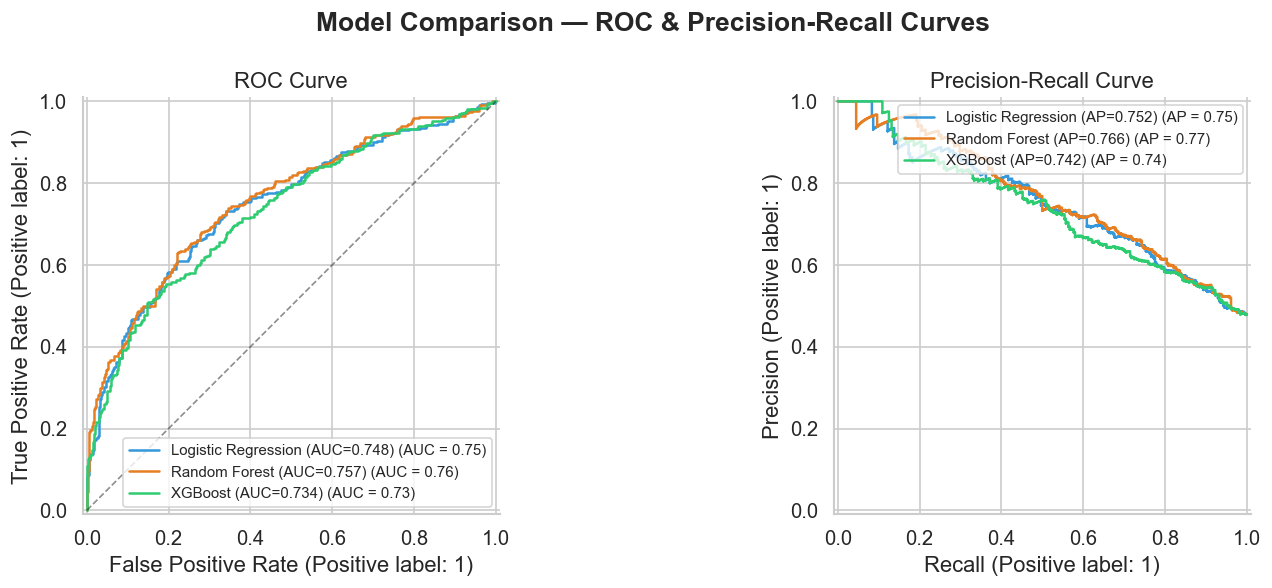

In [19]:
# ── ROC & Precision-Recall curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Comparison — ROC & Precision-Recall Curves', fontweight='bold')

colors = ['#3498db', '#e67e22', '#2ecc71']

for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, res['y_proba'], name=f'{name} (AUC={res["ROC-AUC"]:.3f})',
        ax=axes[0], color=color,
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, res['y_proba'], name=f'{name} (AP={res["PR-AUC"]:.3f})',
        ax=axes[1], color=color,
    )

axes[0].set_title('ROC Curve'); axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[1].set_title('Precision-Recall Curve')

for ax in axes:
    ax.legend(loc='lower right' if ax == axes[0] else 'upper right', fontsize=9)

plt.tight_layout()
plt.show()

=== Best model: Random Forest (ROC-AUC = 0.7574) ===

                 precision    recall  f1-score   support

Non-repurchaser       0.70      0.75      0.72       341
    Repurchaser       0.70      0.65      0.67       312

       accuracy                           0.70       653
      macro avg       0.70      0.70      0.70       653
   weighted avg       0.70      0.70      0.70       653



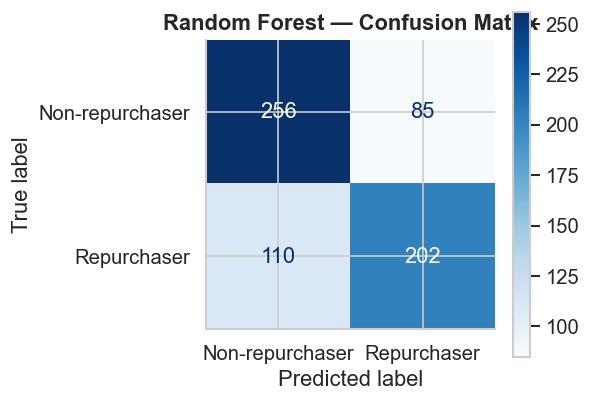

In [20]:
# ── Best model: detailed classification report + confusion matrix ─────────────
best_name = max(results, key=lambda k: results[k]['ROC-AUC'])
best_res  = results[best_name]

print(f'=== Best model: {best_name} (ROC-AUC = {best_res["ROC-AUC"]:.4f}) ===\n')
print(classification_report(y_test, best_res['y_pred'],
                             target_names=['Non-repurchaser', 'Repurchaser']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_res['y_pred'],
    display_labels=['Non-repurchaser', 'Repurchaser'],
    cmap='Blues', ax=ax,
)
ax.set_title(f'{best_name} — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance

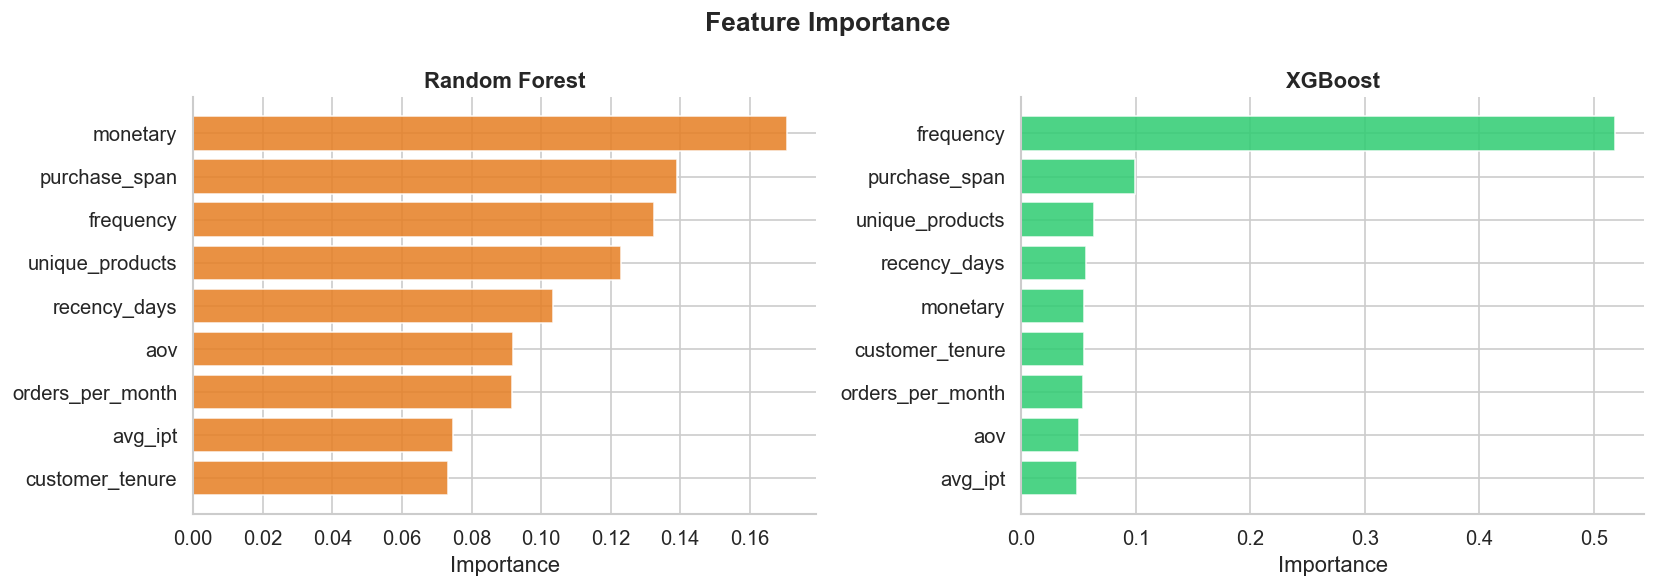

In [21]:
# ── Feature importance for tree-based models ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance', fontweight='bold')

tree_models = {k: v for k, v in results.items() if k != 'Logistic Regression'}
colors_fi   = ['#e67e22', '#2ecc71']

for ax, (name, res), color in zip(axes, tree_models.items(), colors_fi):
    model = res['model']
    importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values()

    ax.barh(importances.index, importances.values,
            color=color, edgecolor='white', alpha=0.85)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

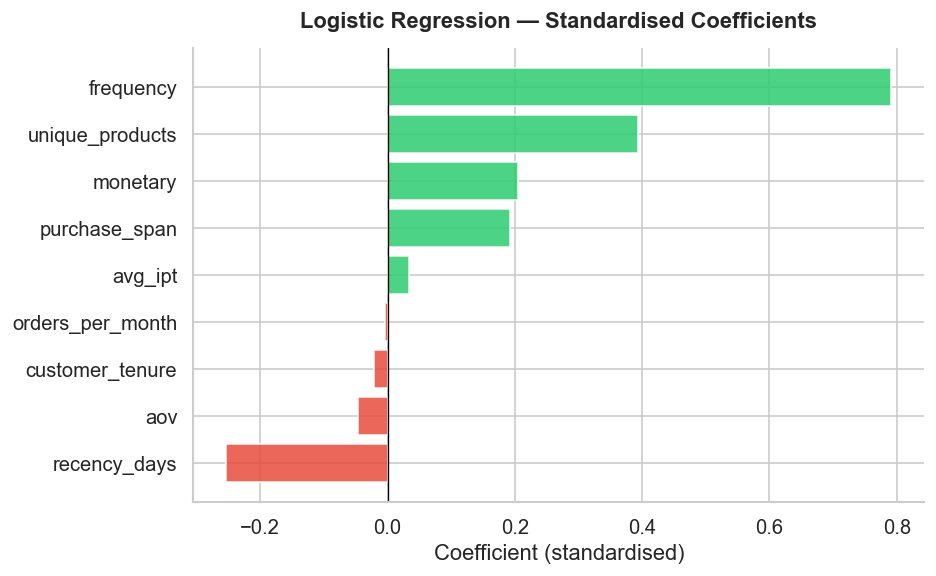

In [22]:
# ── Logistic Regression coefficients ────────────────────────────────────────
lr_model = results['Logistic Regression']['model']
coefs = pd.Series(
    lr_model.named_steps['clf'].coef_[0],
    index=FEATURE_COLS,
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors_coef = ['#e74c3c' if v < 0 else '#2ecc71' for v in coefs.values]
ax.barh(coefs.index, coefs.values, color=colors_coef, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Logistic Regression — Standardised Coefficients', fontweight='bold', pad=12)
ax.set_xlabel('Coefficient (standardised)')
plt.tight_layout()
plt.show()

## 8. Propensity Score Distribution

The propensity score (predicted probability of repurchase) can be used to **rank and prioritise customers** for retention campaigns.


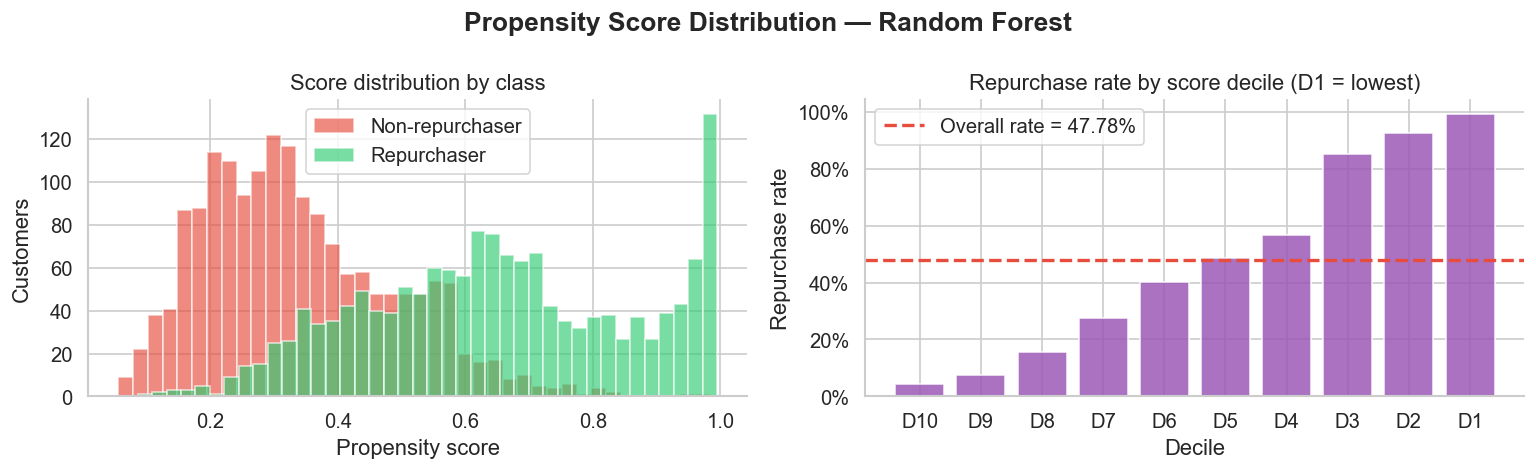

In [23]:
best_model = best_res['model']

# Propensity scores on the full modelling dataset
model_df['propensity_score'] = best_model.predict_proba(X)[:, 1]

# ── Distribution by class ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Propensity Score Distribution — {best_name}', fontweight='bold')

for label, color, name in [(0,'#e74c3c','Non-repurchaser'),(1,'#2ecc71','Repurchaser')]:
    subset = model_df.loc[model_df['is_repurchaser'] == label, 'propensity_score']
    axes[0].hist(subset, bins=40, alpha=0.65, color=color, edgecolor='white', label=name)

axes[0].set_xlabel('Propensity score'); axes[0].set_ylabel('Customers')
axes[0].set_title('Score distribution by class')
axes[0].legend()

# Decile lift chart
model_df_sorted = model_df.sort_values('propensity_score', ascending=False).copy()
model_df_sorted['decile'] = pd.qcut(model_df_sorted['propensity_score'],
                                     q=10, labels=[f'D{i}' for i in range(10, 0, -1)])
decile_summary = (
    model_df_sorted.groupby('decile', observed=True)['is_repurchaser']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'repurchasers', 'count': 'total'})
)
decile_summary['rate'] = decile_summary['repurchasers'] / decile_summary['total']

axes[1].bar(decile_summary.index.astype(str), decile_summary['rate'],
            color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].axhline(y_test.mean(), color='#e74c3c', lw=2, ls='--',
                label=f'Overall rate = {y_test.mean():.2%}')
axes[1].set_title('Repurchase rate by score decile (D1 = lowest)')
axes[1].set_xlabel('Decile'); axes[1].set_ylabel('Repurchase rate')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning (XGBoost)

We use `RandomizedSearchCV` to find a better parameter set for the XGBoost model.

In [24]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 400],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Starting randomized search...")
random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
print(f"Best parameters found: {random_search.best_params_}")

# Evaluate best model
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]
y_pred_best = best_xgb.predict(X_test)
roc_auc_best = roc_auc_score(y_test, y_proba_best)
pr_auc_best = average_precision_score(y_test, y_proba_best)
lift_best = calculate_top_decile_lift(y_test, y_proba_best)

print(f"[Best XGBoost]  ROC-AUC = {roc_auc_best:.4f}  |  PR-AUC = {pr_auc_best:.4f}  |  Top-10% Lift = {lift_best:.2f}")

Starting randomized search...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
[Best XGBoost]  ROC-AUC = 0.7548  |  PR-AUC = 0.7650  |  Top-10% Lift = 1.87
